<a href="https://colab.research.google.com/github/SiyuL2025/math_629_final/blob/main/Transformer_v7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
"""
Memory-Efficient Full-Dataset Pipeline for Colab Free Tier (12GB RAM)
======================================================================
v7 FIXES vs v6:
  1. [CRITICAL] shuffle=True via RandomSampler in training DataLoader
     → breaks autocorrelation, prevents model from seeing correlated batches
  2. [CRITICAL] Normalization is now split-aware: z-score fitted on train
     rows only, then applied to full df — eliminates test data leakage
  3. [MEDIUM]   Removed label_smoothing — conflicts with class_weight on
     imbalanced data; class weights alone are sufficient
  4. [MEDIUM]   Readout changed from mean(dim=1) → last token [:, -1, :]
     → gives more weight to the most recent (most predictive) timestep
  5. [MINOR]    Replaced CosineAnnealingLR with OneCycleLR for better
     warmup behaviour and more stable convergence

Original memory-efficiency features retained:
  - dtype downcasting (float64→float32)
  - Load only needed columns from ETH
  - chunked rolling-zscore
  - del + gc.collect() after every major step
  - Incremental PCA
  - PyTorch Dataset reads from memory-mapped numpy arrays
  - Chunked DataLoader
"""

import kagglehub, os, gc, math, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, RandomSampler
from sklearn.decomposition import IncrementalPCA
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ╔══════════════════════════════════════════════════════════════════╗
# ║                    ★  SETTINGS  ★                               ║
# ║                                                                  ║
# ║  SAMPLE_FRAC  : fraction of data to use (1.0 = all ~1M rows)    ║
# ║                 Try 0.3 first; increase if RAM allows            ║
# ║  DATASET      : "full" | "no_pca" | "no_market" | "full_raw"             ║
# ║  TRANSACTION_COST: 1.5 bps to match CNN                         ║
# ╚══════════════════════════════════════════════════════════════════╝
SAMPLE_FRAC      = 1.0       # ← lower to 0.3~0.5 if still OOM

# ── Model config ──────────────────────────────────────────────────────────────
SEED               = 42
SEQ_LEN            = 30
PREDICTION_HORIZON = 10
D_MODEL            = 64
N_HEADS            = 4
N_LAYERS           = 3
D_FF               = 128
DROPOUT            = 0.1
BATCH_SIZE         = 512
EPOCHS             = 30
LR                 = 1e-3    # FIX 5: OneCycleLR uses this as max_lr
PATIENCE           = 6
BARS_PER_YEAR      = 365 * 24 * 3600 / PREDICTION_HORIZON
META_COLS          = ["label", "future_return", "split"]

torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {DEVICE}")
print(f"Sample frac   : {SAMPLE_FRAC}")


# ══════════════════════════════════════════════════════════════════════════════
# UTILITY: memory report
# ══════════════════════════════════════════════════════════════════════════════
def mem():
    import psutil
    used = psutil.virtual_memory().used / 1e9
    total = psutil.virtual_memory().total / 1e9
    print(f"  [RAM] {used:.1f} / {total:.1f} GB used")


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 1 — Load Data  (dtype=float32 to halve memory vs float64)
# ══════════════════════════════════════════════════════════════════════════════
def load_data():
    print("\n" + "="*50 + "\n1. LOAD DATA\n" + "="*50)
    mem()

    dataset_path = kagglehub.dataset_download(
        "martinsn/high-frequency-crypto-limit-order-book-data")

    eth_cols = ['system_time', 'midpoint', 'spread',
                'bids_notional_0', 'asks_notional_0']

    print("  Loading BTC...")
    btc = pd.read_csv(os.path.join(dataset_path, 'BTC_1sec.csv'),
                      dtype={c: 'float32' for c in
                             pd.read_csv(os.path.join(dataset_path, 'BTC_1sec.csv'),
                                         nrows=0).select_dtypes('float').columns})
    mem()

    print("  Loading ETH (selected columns only)...")
    eth = pd.read_csv(os.path.join(dataset_path, 'ETH_1sec.csv'),
                      usecols=eth_cols,
                      dtype={c: 'float32' for c in
                             ['midpoint','spread','bids_notional_0','asks_notional_0']})
    mem()

    if SAMPLE_FRAC < 1.0:
        n_btc = int(len(btc) * SAMPLE_FRAC)
        n_eth = int(len(eth) * SAMPLE_FRAC)
        btc = btc.iloc[:n_btc].reset_index(drop=True)
        eth = eth.iloc[:n_eth].reset_index(drop=True)
        print(f"  Sampled {SAMPLE_FRAC:.0%}: BTC={btc.shape}, ETH={eth.shape}")

    btc['system_time'] = pd.to_datetime(btc['system_time'], utc=True)
    eth['system_time'] = pd.to_datetime(eth['system_time'], utc=True)
    btc['time_key'] = btc['system_time'].dt.floor('s')
    eth['time_key'] = eth['system_time'].dt.floor('s')

    eth = eth.rename(columns={'midpoint':'eth_midpoint','spread':'eth_spread',
                               'bids_notional_0':'eth_bids_notional_0',
                               'asks_notional_0':'eth_asks_notional_0'})

    df = pd.merge(btc, eth[['time_key','eth_midpoint','eth_spread',
                              'eth_bids_notional_0','eth_asks_notional_0']],
                  on='time_key', how='inner')

    drop_cols = ['time_key', 'system_time']
    if 'Unnamed: 0' in df.columns: drop_cols.append('Unnamed: 0')
    df.drop(columns=drop_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)

    del btc, eth; gc.collect()
    print(f"  Merged df: {df.shape}")
    mem()
    return df


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 2 — Feature Engineering
# ══════════════════════════════════════════════════════════════════════════════
def engineer_features(df):
    print("\n" + "="*50 + "\n2. FEATURE ENGINEERING\n" + "="*50)

    window_short, window_long = 10, 60
    eps = 1e-8

    df['mid_price']  = df['midpoint'].astype('float32')
    df['log_return'] = (np.log(df['mid_price'] / df['mid_price'].shift(1))
                        ).astype('float32')

    df['btc_oimb_1']         = ((df['bids_notional_0'] - df['asks_notional_0']) /
                                 (df['bids_notional_0'] + df['asks_notional_0'] + eps)
                                 ).astype('float32')
    df['btc_volatility_10s'] = df['log_return'].rolling(window_short).std().astype('float32')
    df['btc_volatility_60s'] = df['log_return'].rolling(window_long).std().astype('float32')
    df['btc_momentum_10s']   = df['log_return'].rolling(window_short).sum().astype('float32')
    df['btc_momentum_60s']   = df['log_return'].rolling(window_long).sum().astype('float32')

    df['eth_log_return']     = (np.log(df['eth_midpoint'] / df['eth_midpoint'].shift(1))
                                ).astype('float32')
    df['eth_oimb_1']         = ((df['eth_bids_notional_0'] - df['eth_asks_notional_0']) /
                                 (df['eth_bids_notional_0'] + df['eth_asks_notional_0'] + eps)
                                 ).astype('float32')
    df['eth_volatility_10s'] = df['eth_log_return'].rolling(window_short).std().astype('float32')
    df['eth_volatility_60s'] = df['eth_log_return'].rolling(window_long).std().astype('float32')
    df['eth_momentum_10s']   = df['eth_log_return'].rolling(window_short).sum().astype('float32')
    df['eth_momentum_60s']   = df['eth_log_return'].rolling(window_long).sum().astype('float32')

    df['btc_eth_momentum_diff_10s'] = (df['btc_momentum_10s'] - df['eth_momentum_10s']).astype('float32')
    df['btc_eth_momentum_diff_60s'] = (df['btc_momentum_60s'] - df['eth_momentum_60s']).astype('float32')
    df['btc_eth_vol_ratio_10s']     = (df['btc_volatility_10s'] /
                                        (df['eth_volatility_10s'] + eps)).astype('float32')

    label_threshold = 0.00015
    df['future_return'] = ((df['mid_price'].shift(-PREDICTION_HORIZON) - df['mid_price'])
                            / df['mid_price']).astype('float32')
    df['label'] = np.select(
        [df['future_return'] >  label_threshold,
         df['future_return'] < -label_threshold],
        [1, -1], default=0
    ).astype('int8')

    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    gc.collect()
    print(f"  Shape after dropna: {df.shape}")
    mem()
    return df


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 3 — Classic LOB Factors
# ══════════════════════════════════════════════════════════════════════════════
def add_classic_factors(df):
    print("\n" + "="*50 + "\n3. CLASSIC LOB FACTORS\n" + "="*50)
    eps = 1e-8
    window_short, window_long = 10, 60

    rho, levels = 0.5, 5
    bid_cols = [f'bids_notional_{i}' for i in range(levels)]
    ask_cols = [f'asks_notional_{i}' for i in range(levels)]
    weights  = np.exp(-rho * np.arange(levels)).astype('float32')
    weights /= weights.sum()
    imb_mat  = ((df[bid_cols].values - df[ask_cols].values) /
                 (df[bid_cols].values + df[ask_cols].values + eps))
    df['factor_queue_imbalance'] = (imb_mat * weights).sum(axis=1).astype('float32')
    del imb_mat; gc.collect()

    b0, a0 = df['bids_distance_0'], df['asks_distance_0']
    bv, av = df['bids_notional_0'], df['asks_notional_0']
    e_bid = (bv * (b0 >= b0.shift(1)).astype('float32')
             - bv.shift(1) * (b0 <= b0.shift(1)).astype('float32'))
    e_ask = (av.shift(1) * (a0 >= a0.shift(1)).astype('float32')
             - av * (a0 <= a0.shift(1)).astype('float32'))
    df['factor_ofi']     = (e_bid - e_ask).astype('float32')
    df['factor_ofi_10s'] = df['factor_ofi'].rolling(window_short).sum().astype('float32')
    df['factor_ofi_60s'] = df['factor_ofi'].rolling(window_long).sum().astype('float32')
    del e_bid, e_ask; gc.collect()

    delta_p   = df['log_return']
    delta_ofi = df['factor_ofi'].fillna(0)
    roll_cov  = delta_p.rolling(window_long).cov(delta_ofi)
    roll_var  = delta_ofi.rolling(window_long).var()
    df['factor_kyle_lambda'] = (roll_cov / (roll_var + eps)).astype('float32')
    del roll_cov, roll_var; gc.collect()

    lvls = 10
    total_bid = df[[f'bids_notional_{i}' for i in range(lvls)]].sum(axis=1)
    total_ask = df[[f'asks_notional_{i}' for i in range(lvls)]].sum(axis=1)
    df['factor_depth_ratio']        = (total_ask / (total_bid + eps)).astype('float32')
    df['factor_depth_imb']          = ((total_bid - total_ask) /
                                        (total_bid + total_ask + eps)).astype('float32')
    df['factor_depth_ratio_smooth'] = df['factor_depth_ratio'].rolling(window_short).mean().astype('float32')
    del total_bid, total_ask; gc.collect()

    tick_sign = np.sign(df['log_return'].fillna(0)).replace(0, np.nan).ffill().fillna(1)
    df['factor_tick_sign']         = tick_sign.astype('float32')
    df['factor_tick_momentum_10s'] = tick_sign.rolling(window_short).sum().astype('float32')
    df['factor_tick_momentum_60s'] = tick_sign.rolling(window_long).sum().astype('float32')
    del tick_sign; gc.collect()

    total_notional = (df[[f'bids_notional_{i}' for i in range(5)]].sum(axis=1)
                    + df[[f'asks_notional_{i}' for i in range(5)]].sum(axis=1))
    df['factor_amihud']     = (np.abs(df['log_return']) / (total_notional + eps)).astype('float32')
    df['factor_amihud_60s'] = df['factor_amihud'].rolling(window_long).mean().astype('float32')
    del total_notional; gc.collect()

    classic_factor_cols = [
        'factor_queue_imbalance',
        'factor_ofi', 'factor_ofi_10s', 'factor_ofi_60s',
        'factor_kyle_lambda',
        'factor_depth_ratio', 'factor_depth_imb', 'factor_depth_ratio_smooth',
        'factor_tick_sign', 'factor_tick_momentum_10s', 'factor_tick_momentum_60s',
        'factor_amihud', 'factor_amihud_60s',
    ]
    df.dropna(subset=classic_factor_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)
    gc.collect()
    print(f"  Shape after factors: {df.shape}")
    mem()
    return df, classic_factor_cols


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 4 — Rolling Z-score  (FIX 2: split-aware, no leakage)
# ══════════════════════════════════════════════════════════════════════════════
def rolling_zscore_split_aware(df, cols, split_idx, window=3600, min_p=60):
    """
    FIX 2: Compute rolling mean/std using ONLY training rows ([:split_idx]),
    then apply the final training statistics to normalise the full dataframe.
    This prevents any test-set information from leaking into the normalisation.
    Processing 10 columns at a time keeps peak memory low.
    """
    chunk = 10
    for i in range(0, len(cols), chunk):
        c = cols[i:i+chunk]
        # Compute rolling stats on training portion only
        train_series = df[c].iloc[:split_idx]
        rm = train_series.rolling(window=window, min_periods=min_p).mean().iloc[-1]
        rs = train_series.rolling(window=window, min_periods=min_p).std().iloc[-1]
        # Apply to the full dataframe
        df[c] = ((df[c] - rm) / (rs + 1e-8)).astype('float32')
        del train_series, rm, rs; gc.collect()


def normalise(df, lob_features, market_state_cols, classic_factor_cols, split_idx):
    print("\n" + "="*50 + "\n4. NORMALISATION (split-aware — no leakage)\n" + "="*50)
    print("  Rolling Z-score — LOB features ...")
    rolling_zscore_split_aware(df, lob_features, split_idx)
    gc.collect(); mem()

    print("  Rolling Z-score — market features ...")
    rolling_zscore_split_aware(df, market_state_cols, split_idx)
    gc.collect()

    print("  Rolling Z-score — classic factors ...")
    rolling_zscore_split_aware(df, classic_factor_cols, split_idx)
    gc.collect()

    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"  Shape after normalisation: {df.shape}")
    mem()
    return df


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 5 — Incremental PCA
# ══════════════════════════════════════════════════════════════════════════════
def run_incremental_pca(df, lob_features, split_idx, n_components=10, batch_size=50000):
    print("\n" + "="*50 + "\n5. INCREMENTAL PCA\n" + "="*50)
    print(f"  n_components={n_components}, batch_size={batch_size:,}")

    ipca = IncrementalPCA(n_components=n_components)

    X_train_lob = df[lob_features].values[:split_idx]
    for start in range(0, len(X_train_lob), batch_size):
        ipca.partial_fit(X_train_lob[start:start+batch_size])
    print(f"  Cumulative variance explained: "
          f"{ipca.explained_variance_ratio_.sum():.3f}")

    n_total = len(df)
    X_pca   = np.empty((n_total, n_components), dtype='float32')
    X_lob_all = df[lob_features].values
    for start in range(0, n_total, batch_size):
        end = min(start + batch_size, n_total)
        X_pca[start:end] = ipca.transform(X_lob_all[start:end]).astype('float32')

    del X_train_lob, X_lob_all; gc.collect()

    pca_cols = [f'pca_{i+1}' for i in range(n_components)]
    pca_df   = pd.DataFrame(X_pca, columns=pca_cols, index=df.index)
    del X_pca; gc.collect()
    mem()
    return pca_df, pca_cols


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 6 — Assemble Datasets
# ══════════════════════════════════════════════════════════════════════════════
def assemble_and_save(df, pca_df, pca_cols, lob_features,
                      market_state_cols, classic_factor_cols, split_idx):
    print("\n" + "="*50 + "\n6. ASSEMBLE DATASETS\n" + "="*50)

    labels       = df['label'].values.astype('int8')
    future_ret   = df['future_return'].values.astype('float32')

    def extract(feature_cols_list):
        parts = []
        for fc in feature_cols_list:
            if isinstance(fc, pd.DataFrame):
                parts.append(fc.values.astype('float32'))
            else:
                parts.append(df[fc].values.astype('float32'))
        X = np.concatenate(parts, axis=1)
        return (X[:split_idx], X[split_idx:],
                (labels[:split_idx] + 1).astype(np.int64),
                (labels[split_idx:] + 1).astype(np.int64),
                future_ret[split_idx:])

    configs = {
        "full_raw":    [lob_features, market_state_cols, classic_factor_cols],
        "full":      [pca_df[pca_cols], market_state_cols, classic_factor_cols],
        "no_pca":    [lob_features, classic_factor_cols],
        "no_market": [pca_df[pca_cols], classic_factor_cols],
    }

    print(f"  Extracting dataset: '{DATASET}'")
    X_train, X_test, y_train, y_test, future_ret_test = extract(configs[DATASET])
    del df, pca_df; gc.collect()

    print(f"  X_train: {X_train.shape}  X_test: {X_test.shape}")
    mem()
    return X_train, X_test, y_train, y_test, future_ret_test, split_idx


# ══════════════════════════════════════════════════════════════════════════════
# MODEL
# ══════════════════════════════════════════════════════════════════════════════
class LOBDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X, self.y, self.seq_len = X, y, seq_len

    def __len__(self):
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, i):
        x = torch.from_numpy(self.X[i : i + self.seq_len])
        y = torch.tensor(int(self.y[i + self.seq_len - 1]), dtype=torch.long)
        return x, y


def build_loaders(X_train, X_test, y_train, y_test):
    counts  = np.bincount(y_train, minlength=3).astype(float)
    class_w = torch.tensor(counts.sum() / (3 * counts), dtype=torch.float32).to(DEVICE)

    train_ds = LOBDataset(X_train, y_train, SEQ_LEN)
    test_ds  = LOBDataset(X_test,  y_test,  SEQ_LEN)

    # FIX 1: Use RandomSampler to shuffle sequence start indices each epoch.
    # This breaks the autocorrelation in gradient updates that caused
    # progressive degradation across epochs in v6.
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        sampler=RandomSampler(train_ds),   # ← KEY FIX
        num_workers=2,
        pin_memory=(DEVICE.type == 'cuda')
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,                     # test set: always in order
        num_workers=2,
        pin_memory=(DEVICE.type == 'cuda')
    )

    print(f"Train samples: {len(train_loader.dataset):,} | "
          f"Test samples: {len(test_loader.dataset):,}")
    print(f"Class weights (down/flat/up): {class_w.cpu().numpy().round(3)}")
    return train_loader, test_loader, class_w


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])


class LOBTransformer(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.proj    = nn.Linear(n_features, D_MODEL)
        self.pos_enc = PositionalEncoding(D_MODEL, dropout=DROPOUT)
        enc_layer    = nn.TransformerEncoderLayer(
            D_MODEL, N_HEADS, D_FF, DROPOUT,
            activation="gelu", batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, N_LAYERS, norm=nn.LayerNorm(D_MODEL))
        self.head    = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL // 2), nn.GELU(), nn.Dropout(DROPOUT),
            nn.Linear(D_MODEL // 2, 3))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        encoded = self.encoder(self.pos_enc(self.proj(x)))
        # FIX 4: Use last token instead of mean pooling.
        # The most recent timestep carries the most predictive signal
        # for short-horizon price movement; mean pooling dilutes it.
        return self.head(encoded[:, -1, :])


def train_model(model, train_loader, test_loader, class_w):
    # FIX 3: Removed label_smoothing.
    # It conflicts with class_weight on imbalanced data — the two objectives
    # partially cancel each other. class_weight alone is sufficient.
    criterion = nn.CrossEntropyLoss(weight=class_w)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    # FIX 5: OneCycleLR provides a linear warmup followed by cosine decay.
    # This prevents the high initial LR from destabilising training on
    # autocorrelated financial data, which was a secondary cause of
    # progressive val loss degradation in v6.
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=LR,
        steps_per_epoch=len(train_loader),
        epochs=EPOCHS,
        pct_start=0.1,        # 10% of training as warmup
        anneal_strategy='cos'
    )

    history   = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_acc, best_state, patience_cnt = 0.0, None, 0

    for epoch in range(1, EPOCHS + 1):
        model.train(); running = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()   # OneCycleLR steps every batch, not every epoch
            running += loss.item() * len(yb)
        train_loss = running / len(train_loader.dataset)

        model.eval(); vloss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                logits  = model(Xb)
                vloss  += criterion(logits, yb).item() * len(yb)
                correct += (logits.argmax(1) == yb).sum().item()
                total   += len(yb)
        val_loss = vloss / total
        val_acc  = correct / total
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"Ep {epoch:3d}/{EPOCHS} | Train {train_loss:.4f} | "
              f"Val {val_loss:.4f} | Acc {val_acc:.4f} | "
              f"LR {scheduler.get_last_lr()[0]:.2e}")

        if val_acc > best_acc:
            best_acc, patience_cnt = val_acc, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"Early stop. Best acc: {best_acc:.4f}"); break

    model.load_state_dict(best_state)
    return history, best_acc


def predict(model, test_loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            preds.append(model(Xb.to(DEVICE)).argmax(1).cpu().numpy())
            labels.append(yb.numpy())
    return np.concatenate(preds), np.concatenate(labels)


# ══════════════════════════════════════════════════════════════════════════════
# 6.1 Statistical Metrics
# ══════════════════════════════════════════════════════════════════════════════
def statistical_metrics(y_true, y_pred):
    print("\n" + "="*60 + "\n  6.1  STATISTICAL PREDICTION METRICS\n" + "="*60)
    acc = (y_pred == y_true).mean()
    print(f"\nOverall Accuracy: {acc:.4f}  ({acc*100:.2f}%)\n")
    print(classification_report(y_true, y_pred,
          target_names=["Down (-1)","Flat (0)","Up (+1)"], digits=4))
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=[0,1,2], zero_division=0)
    print(f"\n{'Class':<12}{'Precision':>10}{'Recall':>10}{'F1':>10}{'Support':>10}")
    print("-"*46)
    for i, n in enumerate(["Down (-1)","Flat (0)","Up (+1)"]):
        print(f"{n:<12}{prec[i]:>10.4f}{rec[i]:>10.4f}{f1[i]:>10.4f}{sup[i]:>10,}")
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, support=sup)


# ══════════════════════════════════════════════════════════════════════════════
# 6.2 Backtesting
# ══════════════════════════════════════════════════════════════════════════════
def backtest(y_pred, future_ret_test, transaction_cost=0.00015):
    print("\n" + "="*60 + "\n  6.2  ECONOMIC EVALUATION & BACKTESTING\n" + "="*60)
    print(f"  Return : future_return (10-sec)  |  Stride : {PREDICTION_HORIZON}  |  "
          f"Ann : {BARS_PER_YEAR:,.0f}  |  Cost : {transaction_cost*1e4:.1f}bps")

    aligned = future_ret_test[SEQ_LEN - 1:].astype(np.float64)
    n       = min(len(y_pred), len(aligned))
    y_pred, aligned = y_pred[:n], aligned[:n]

    signal_map = {0: -1, 1: 0, 2: 1}
    positions  = np.array([signal_map[p] for p in y_pred], dtype=np.float64)

    idx        = np.arange(0, len(positions), PREDICTION_HORIZON)
    pos_s      = positions[idx]
    ret_s      = aligned[idx]
    trades     = (np.diff(pos_s, prepend=0) != 0).astype(float)
    strat_ret  = pos_s * ret_s - trades * transaction_cost
    bh_ret     = ret_s

    cum_strat  = np.cumprod(1 + strat_ret) - 1
    cum_bh     = np.cumprod(1 + bh_ret)   - 1

    def sr(r): return (r.mean() / (r.std() + 1e-8)) * np.sqrt(BARS_PER_YEAR)
    def mdd(c):
        e = 1 + c; p = np.maximum.accumulate(e)
        return ((e - p) / (p + 1e-8)).min()

    print(f"\n{'Metric':<30}{'Strategy':>12}{'Buy & Hold':>12}")
    print("-"*56)
    print(f"{'Cumulative Return':<30}{cum_strat[-1]:>12.4f}{cum_bh[-1]:>12.4f}")
    print(f"{'Annualised Sharpe':<30}{sr(strat_ret):>12.4f}{sr(bh_ret):>12.4f}")
    print(f"{'Max Drawdown':<30}{mdd(cum_strat):>12.4f}{mdd(cum_bh):>12.4f}")
    print(f"{'Total Trades':<30}{int(trades.sum()):>12,}{'—':>12}")
    print(f"{'Turnover/bar':<30}{trades.mean():>12.4f}{'—':>12}")

    return dict(cum_strat=cum_strat[-1], cum_bh=cum_bh[-1],
                sharpe_strat=sr(strat_ret), sharpe_bh=sr(bh_ret),
                mdd_strat=mdd(cum_strat), mdd_bh=mdd(cum_bh)), \
           cum_strat, cum_bh, strat_ret


# ══════════════════════════════════════════════════════════════════════════════
# Plots
# ══════════════════════════════════════════════════════════════════════════════
def plot_results(history, y_pred, y_true, cum_strat, cum_bh, strat_ret, title=""):
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f"Transformer LOB v7 — {title}", fontsize=15)
    gs  = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.35)

    ep = range(1, len(history["train_loss"]) + 1)
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.plot(ep, history["train_loss"], label="Train", color="steelblue")
    ax0.plot(ep, history["val_loss"],   label="Val",   color="tomato")
    ax0.set_title("Loss"); ax0.legend(); ax0.grid(alpha=0.3)

    ax1 = fig.add_subplot(gs[0, 1])
    best = max(history["val_acc"])
    ax1.plot(ep, history["val_acc"], color="seagreen")
    ax1.axhline(best, color="tomato", linestyle="--", label=f"Best={best:.4f}")
    ax1.set_title("Val Accuracy"); ax1.legend(); ax1.grid(alpha=0.3)

    ax2 = fig.add_subplot(gs[0, 2])
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d", cmap="Blues",
                ax=ax2, xticklabels=["Down","Flat","Up"],
                yticklabels=["Down","Flat","Up"])
    ax2.set_title("Confusion Matrix")

    ax3 = fig.add_subplot(gs[1, :2])
    ax3.plot(cum_strat*100, label="Strategy",       color="steelblue", lw=1.2)
    ax3.plot(cum_bh*100,    label="Buy & Hold BTC", color="tomato", ls="--", alpha=0.8)
    ax3.axhline(0, color="black", lw=0.6, ls=":")
    ax3.set_title(f"Cumulative Return (stride={PREDICTION_HORIZON}s, future_return)")
    ax3.set_xlabel(f"Non-overlapping {PREDICTION_HORIZON}s steps")
    ax3.set_ylabel("Cumulative Return (%)"); ax3.legend(); ax3.grid(alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 2])
    W    = max(50, len(strat_ret)//20)
    r_mu = np.convolve(strat_ret, np.ones(W)/W, mode="valid")
    r_sd = np.array([strat_ret[i:i+W].std() for i in range(len(strat_ret)-W+1)])
    ax4.plot(r_mu/(r_sd+1e-8)*np.sqrt(BARS_PER_YEAR), color="darkorchid", lw=0.9)
    ax4.axhline(0, color="black", lw=0.6, ls=":")
    ax4.set_title(f"Rolling Sharpe ({W}-step)"); ax4.grid(alpha=0.3)

    plt.tight_layout(); plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════════
def run():
    lob_features = []
    for i in range(15):
        lob_features.extend([f'bids_distance_{i}', f'asks_distance_{i}',
                              f'bids_notional_{i}', f'asks_notional_{i}'])
    market_state_cols = [
        'spread','btc_oimb_1','btc_volatility_10s','btc_volatility_60s',
        'btc_momentum_10s','btc_momentum_60s',
        'eth_spread','eth_oimb_1','eth_volatility_10s','eth_volatility_60s',
        'eth_momentum_10s','eth_momentum_60s',
        'btc_eth_momentum_diff_10s','btc_eth_momentum_diff_60s','btc_eth_vol_ratio_10s',
    ]

    # ── Pipeline ──────────────────────────────────────────────────────────────
    df                              = load_data()
    df                              = engineer_features(df)
    df, classic_factor_cols         = add_classic_factors(df)

    # FIX 2: Compute the split index BEFORE normalisation so that the
    # z-score statistics are derived from training rows only.
    split_idx = int(len(df) * 0.8)
    print(f"\n  Split index: {split_idx:,} (train) / {len(df)-split_idx:,} (test)")

    df = normalise(df, lob_features, market_state_cols, classic_factor_cols, split_idx)

    # Recompute split_idx after dropna (row count may have changed slightly)
    split_idx = int(len(df) * 0.8)

    pca_df, pca_cols = run_incremental_pca(df, lob_features, split_idx,
                                           n_components=10, batch_size=50_000)

    (X_train, X_test,
     y_train, y_test,
     future_ret_test, split_idx)    = assemble_and_save(df, pca_df, pca_cols,
                                                         lob_features,
                                                         market_state_cols,
                                                         classic_factor_cols,
                                                         split_idx)
    del df, pca_df; gc.collect(); mem()

    # ── Model ─────────────────────────────────────────────────────────────────
    train_ld, test_ld, class_w = build_loaders(X_train, X_test, y_train, y_test)
    model = LOBTransformer(n_features=X_train.shape[1]).to(DEVICE)
    n_p   = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model params: {n_p:,}  |  Features: {X_train.shape[1]}")

    print("\n--- Training ---")
    history, best_acc = train_model(model, train_ld, test_ld, class_w)

    print("\n--- Prediction ---")
    y_pred, y_true = predict(model, test_ld)

    stat = statistical_metrics(y_true, y_pred)
    bt, cum_strat, cum_bh, strat_ret = backtest(y_pred, future_ret_test, TRANSACTION_COST)

    plot_results(history, y_pred, y_true, cum_strat, cum_bh, strat_ret,
                 title=f"dataset='{DATASET}' | acc={best_acc:.4f} | n={SAMPLE_FRAC:.0%}")
    return model, history, stat, bt


Device        : cuda
Sample frac   : 1.0



1. LOAD DATA
  [RAM] 2.9 / 13.6 GB used
Using Colab cache for faster access to the 'high-frequency-crypto-limit-order-book-data' dataset.
  Loading BTC...
  [RAM] 5.0 / 13.6 GB used
  Loading ETH (selected columns only)...
  [RAM] 5.1 / 13.6 GB used
  Merged df: (1030670, 158)
  [RAM] 4.9 / 13.6 GB used

2. FEATURE ENGINEERING
  Shape after dropna: (1030600, 176)
  [RAM] 4.9 / 13.6 GB used

3. CLASSIC LOB FACTORS
  Shape after factors: (1030540, 189)
  [RAM] 6.2 / 13.6 GB used

  Split index: 824,432 (train) / 206,108 (test)

4. NORMALISATION (split-aware — no leakage)
  Rolling Z-score — LOB features ...
  [RAM] 4.9 / 13.6 GB used
  Rolling Z-score — market features ...
  Rolling Z-score — classic factors ...
  Shape after normalisation: (1030540, 189)
  [RAM] 4.8 / 13.6 GB used

5. INCREMENTAL PCA
  n_components=10, batch_size=50,000
  Cumulative variance explained: 0.573
  [RAM] 4.8 / 13.6 GB used

6. ASSEMBLE DATASETS
  Extracting dataset: 'full'
  X_train: (824432, 38)  X_test: (

/tmp/ipykernel_4770/1788739781.py:446: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, N_LAYERS, norm=nn.LayerNorm(D_MODEL))


Ep   1/30 | Train 1.0102 | Val 0.9698 | Acc 0.4443 | LR 2.80e-04
Ep   2/30 | Train 0.9647 | Val 0.9652 | Acc 0.4498 | LR 7.60e-04
Ep   3/30 | Train 0.9568 | Val 0.9623 | Acc 0.4580 | LR 1.00e-03
Ep   4/30 | Train 0.9501 | Val 0.9662 | Acc 0.4717 | LR 9.97e-04
Ep   5/30 | Train 0.9431 | Val 0.9652 | Acc 0.4543 | LR 9.87e-04
Ep   6/30 | Train 0.9359 | Val 0.9809 | Acc 0.4556 | LR 9.70e-04
Ep   7/30 | Train 0.9267 | Val 0.9888 | Acc 0.4560 | LR 9.47e-04
Ep   8/30 | Train 0.9165 | Val 0.9869 | Acc 0.4448 | LR 9.18e-04
Ep   9/30 | Train 0.9056 | Val 1.0000 | Acc 0.4218 | LR 8.83e-04
Ep  10/30 | Train 0.8937 | Val 1.0042 | Acc 0.4369 | LR 8.43e-04
Early stop. Best acc: 0.4717

--- Prediction ---

  6.1  STATISTICAL PREDICTION METRICS

Overall Accuracy: 0.4717  (47.17%)

              precision    recall  f1-score   support

   Down (-1)     0.3917    0.5494    0.4573     54928
    Flat (0)     0.7065    0.3733    0.4885     97696
     Up (+1)     0.3948    0.5718    0.4671     53455

    acc

/tmp/ipykernel_4770/1788739781.py:643: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


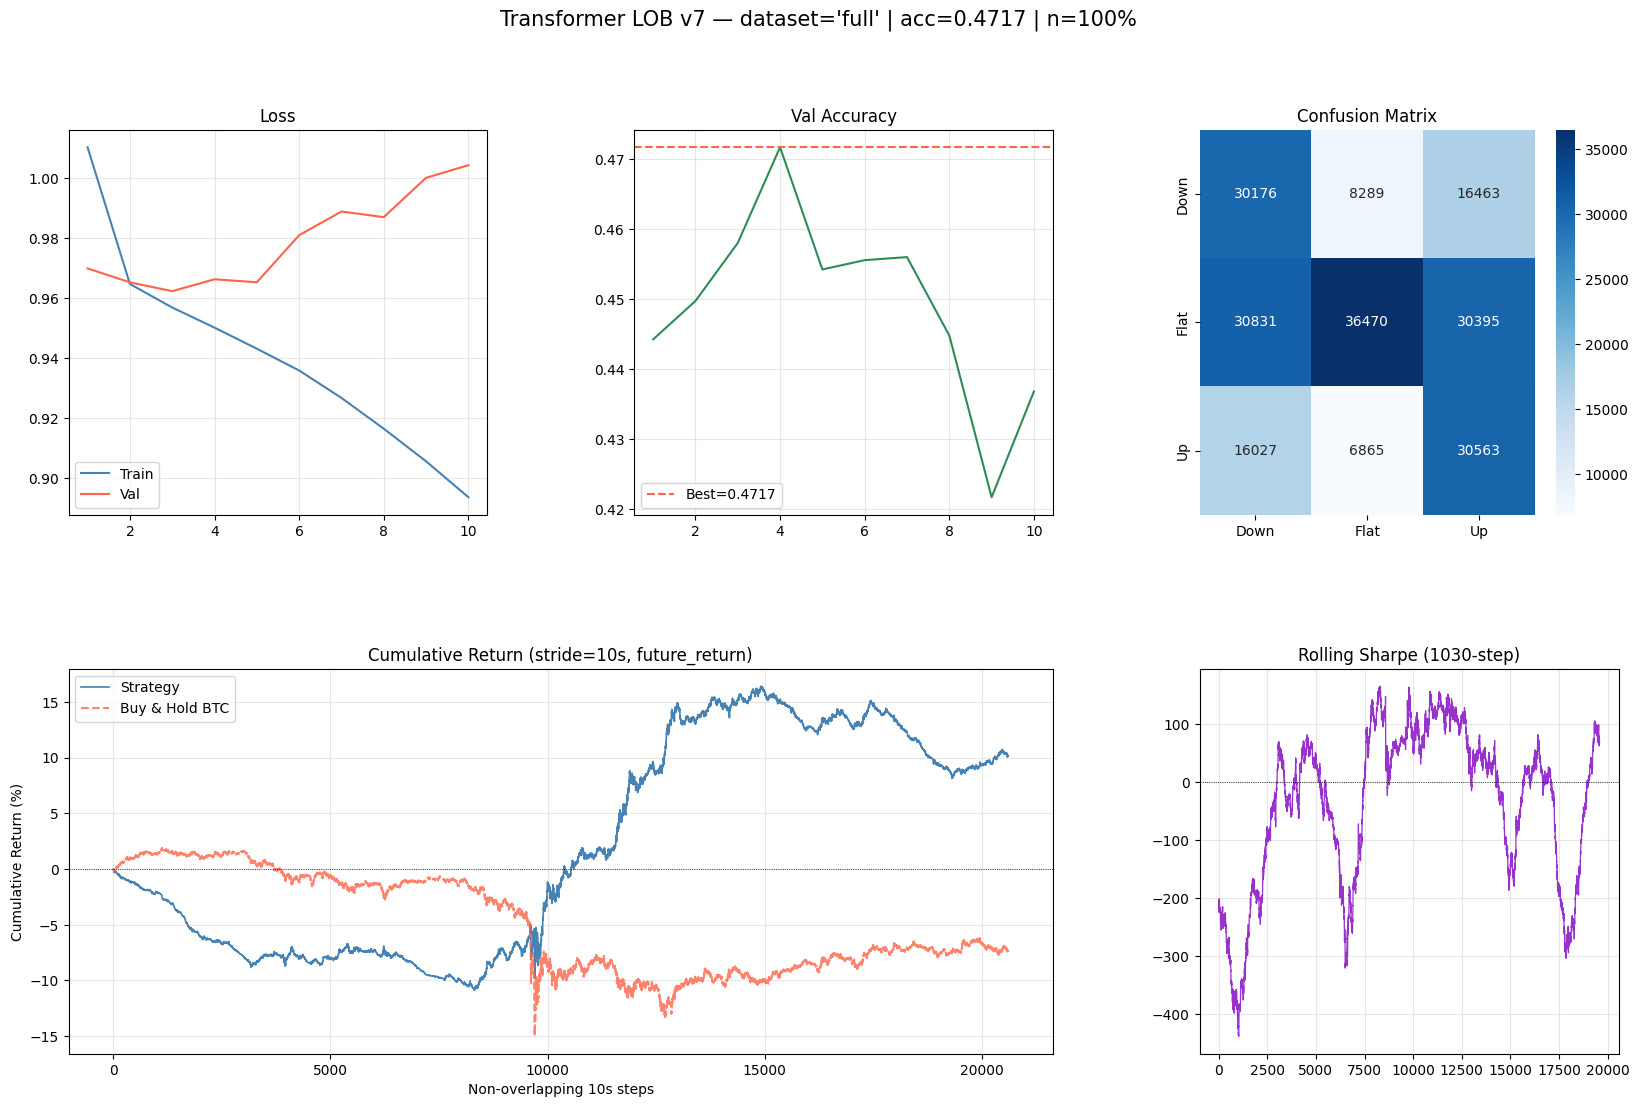

In [4]:
DATASET          = "full"
TRANSACTION_COST = 0.00015
model, history, stat_metrics, bt_metrics = run()


1. LOAD DATA
  [RAM] 3.8 / 13.6 GB used
Using Colab cache for faster access to the 'high-frequency-crypto-limit-order-book-data' dataset.
  Loading BTC...
  [RAM] 5.3 / 13.6 GB used
  Loading ETH (selected columns only)...
  [RAM] 5.2 / 13.6 GB used
  Merged df: (1030670, 158)
  [RAM] 5.1 / 13.6 GB used

2. FEATURE ENGINEERING
  Shape after dropna: (1030600, 176)
  [RAM] 5.1 / 13.6 GB used

3. CLASSIC LOB FACTORS
  Shape after factors: (1030540, 189)
  [RAM] 6.3 / 13.6 GB used

  Split index: 824,432 (train) / 206,108 (test)

4. NORMALISATION (split-aware — no leakage)
  Rolling Z-score — LOB features ...
  [RAM] 5.1 / 13.6 GB used
  Rolling Z-score — market features ...
  Rolling Z-score — classic factors ...
  Shape after normalisation: (1030540, 189)
  [RAM] 5.0 / 13.6 GB used

5. INCREMENTAL PCA
  n_components=10, batch_size=50,000
  Cumulative variance explained: 0.573
  [RAM] 5.0 / 13.6 GB used

6. ASSEMBLE DATASETS
  Extracting dataset: 'no_pca'
  X_train: (824432, 73)  X_test:

/tmp/ipykernel_4770/2872524565.py:447: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, N_LAYERS, norm=nn.LayerNorm(D_MODEL))


Ep   1/30 | Train 1.0158 | Val 0.9807 | Acc 0.4615 | LR 2.80e-04
Ep   2/30 | Train 0.9790 | Val 0.9774 | Acc 0.4438 | LR 7.60e-04
Ep   3/30 | Train 0.9700 | Val 0.9758 | Acc 0.4624 | LR 1.00e-03
Ep   4/30 | Train 0.9619 | Val 0.9800 | Acc 0.4642 | LR 9.97e-04
Ep   5/30 | Train 0.9531 | Val 0.9838 | Acc 0.4754 | LR 9.87e-04
Ep   6/30 | Train 0.9427 | Val 0.9930 | Acc 0.4628 | LR 9.70e-04
Ep   7/30 | Train 0.9308 | Val 1.0006 | Acc 0.4344 | LR 9.47e-04
Ep   8/30 | Train 0.9182 | Val 1.0128 | Acc 0.4340 | LR 9.18e-04
Ep   9/30 | Train 0.9054 | Val 1.0200 | Acc 0.4190 | LR 8.83e-04
Ep  10/30 | Train 0.8929 | Val 1.0466 | Acc 0.4352 | LR 8.43e-04
Ep  11/30 | Train 0.8808 | Val 1.0473 | Acc 0.4210 | LR 7.99e-04
Early stop. Best acc: 0.4754

--- Prediction ---

  6.1  STATISTICAL PREDICTION METRICS

Overall Accuracy: 0.4754  (47.54%)

              precision    recall  f1-score   support

   Down (-1)     0.3918    0.5244    0.4485     54928
    Flat (0)     0.6773    0.4098    0.5106     976

/tmp/ipykernel_4770/2872524565.py:644: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


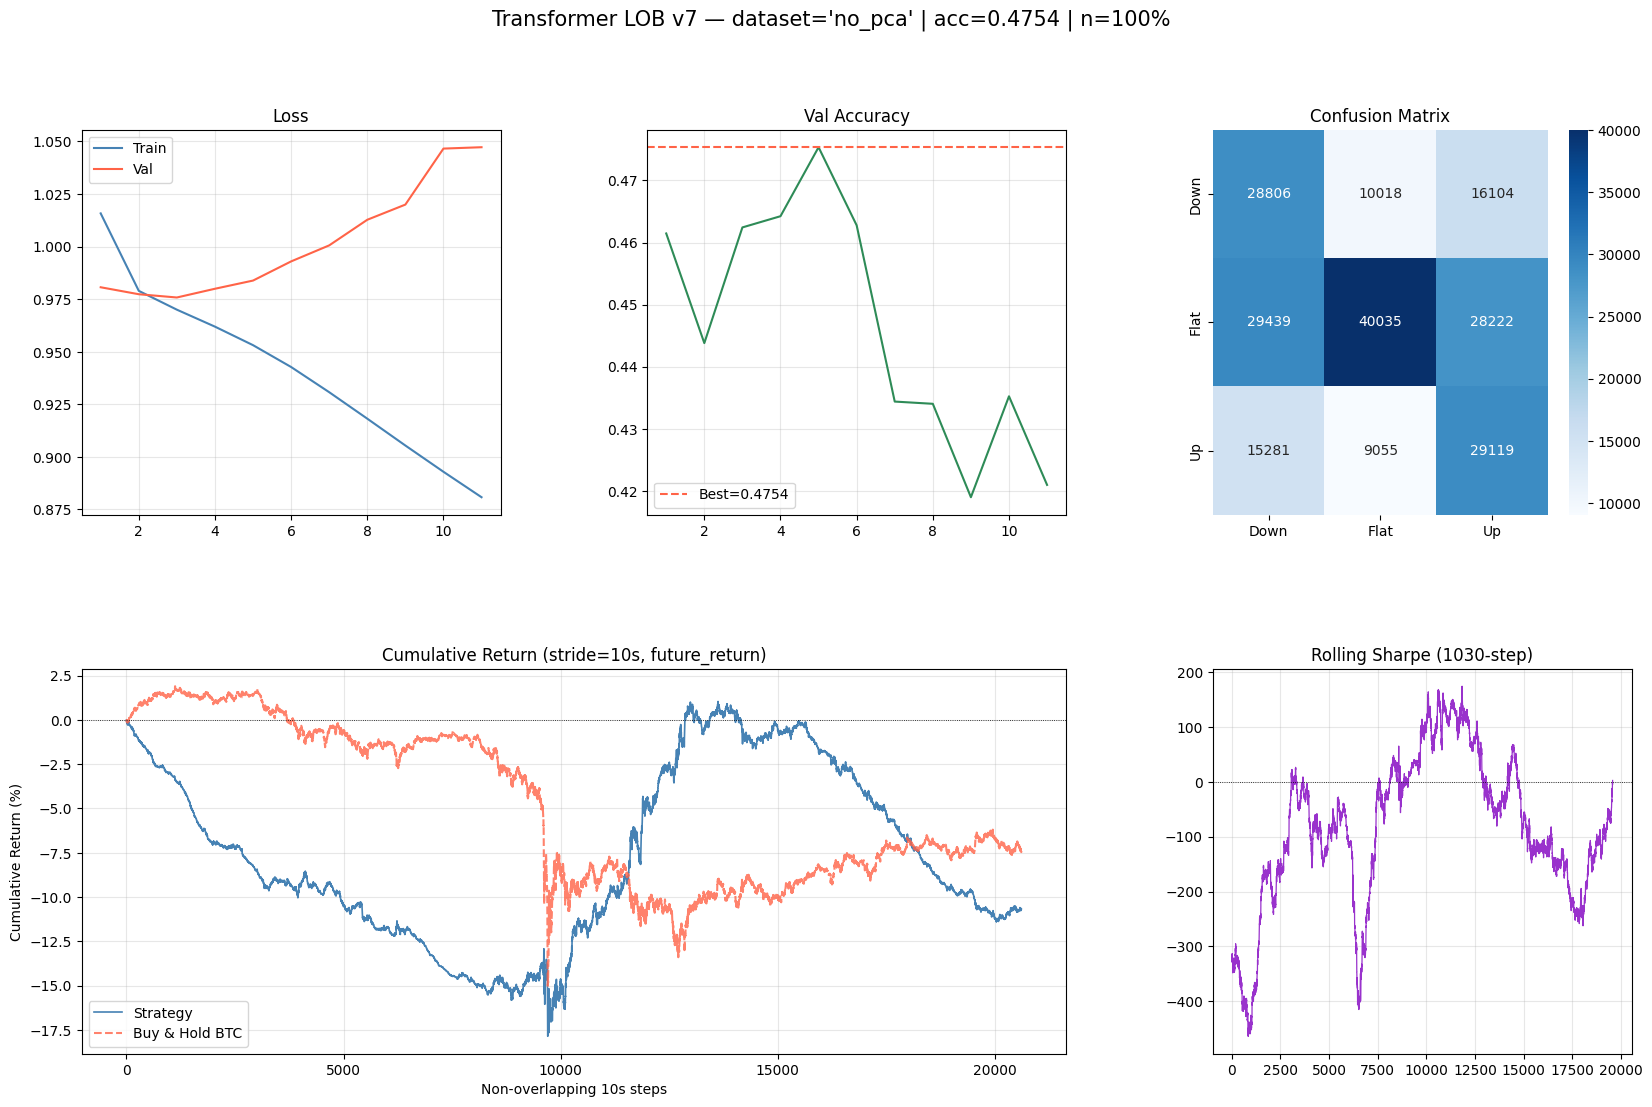

In [7]:
DATASET          = "no_pca"
TRANSACTION_COST = 0.00015
model, history, stat_metrics, bt_metrics = run()


1. LOAD DATA
  [RAM] 2.1 / 13.6 GB used
Using Colab cache for faster access to the 'high-frequency-crypto-limit-order-book-data' dataset.
  Loading BTC...
  [RAM] 4.4 / 13.6 GB used
  Loading ETH (selected columns only)...
  [RAM] 4.3 / 13.6 GB used
  Merged df: (1030670, 158)
  [RAM] 4.0 / 13.6 GB used

2. FEATURE ENGINEERING
  Shape after dropna: (1030600, 176)
  [RAM] 4.0 / 13.6 GB used

3. CLASSIC LOB FACTORS
  Shape after factors: (1030540, 189)
  [RAM] 5.3 / 13.6 GB used

  Split index: 824,432 (train) / 206,108 (test)

4. NORMALISATION (split-aware — no leakage)
  Rolling Z-score — LOB features ...
  [RAM] 4.0 / 13.6 GB used
  Rolling Z-score — market features ...
  Rolling Z-score — classic factors ...
  Shape after normalisation: (1030540, 189)
  [RAM] 3.9 / 13.6 GB used

5. INCREMENTAL PCA
  n_components=10, batch_size=50,000
  Cumulative variance explained: 0.573
  [RAM] 3.9 / 13.6 GB used

6. ASSEMBLE DATASETS
  Extracting dataset: 'no_market'
  X_train: (824432, 23)  X_te

/tmp/ipykernel_4770/1788739781.py:446: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, N_LAYERS, norm=nn.LayerNorm(D_MODEL))


Ep   1/30 | Train 1.0229 | Val 0.9857 | Acc 0.4684 | LR 2.80e-04
Ep   2/30 | Train 0.9814 | Val 0.9802 | Acc 0.4595 | LR 7.60e-04
Ep   3/30 | Train 0.9742 | Val 0.9798 | Acc 0.4726 | LR 1.00e-03
Ep   4/30 | Train 0.9682 | Val 0.9791 | Acc 0.4445 | LR 9.97e-04
Ep   5/30 | Train 0.9632 | Val 0.9843 | Acc 0.4401 | LR 9.87e-04
Ep   6/30 | Train 0.9580 | Val 0.9821 | Acc 0.4515 | LR 9.70e-04
Ep   7/30 | Train 0.9520 | Val 0.9877 | Acc 0.4446 | LR 9.47e-04
Ep   8/30 | Train 0.9457 | Val 0.9896 | Acc 0.4395 | LR 9.18e-04
Ep   9/30 | Train 0.9384 | Val 0.9989 | Acc 0.4469 | LR 8.83e-04
Early stop. Best acc: 0.4726

--- Prediction ---

  6.1  STATISTICAL PREDICTION METRICS

Overall Accuracy: 0.4726  (47.26%)

              precision    recall  f1-score   support

   Down (-1)     0.3776    0.5247    0.4391     54928
    Flat (0)     0.6817    0.4003    0.5044     97696
     Up (+1)     0.4071    0.5512    0.4683     53455

    accuracy                         0.4726    206079
   macro avg     0

/tmp/ipykernel_4770/1788739781.py:643: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


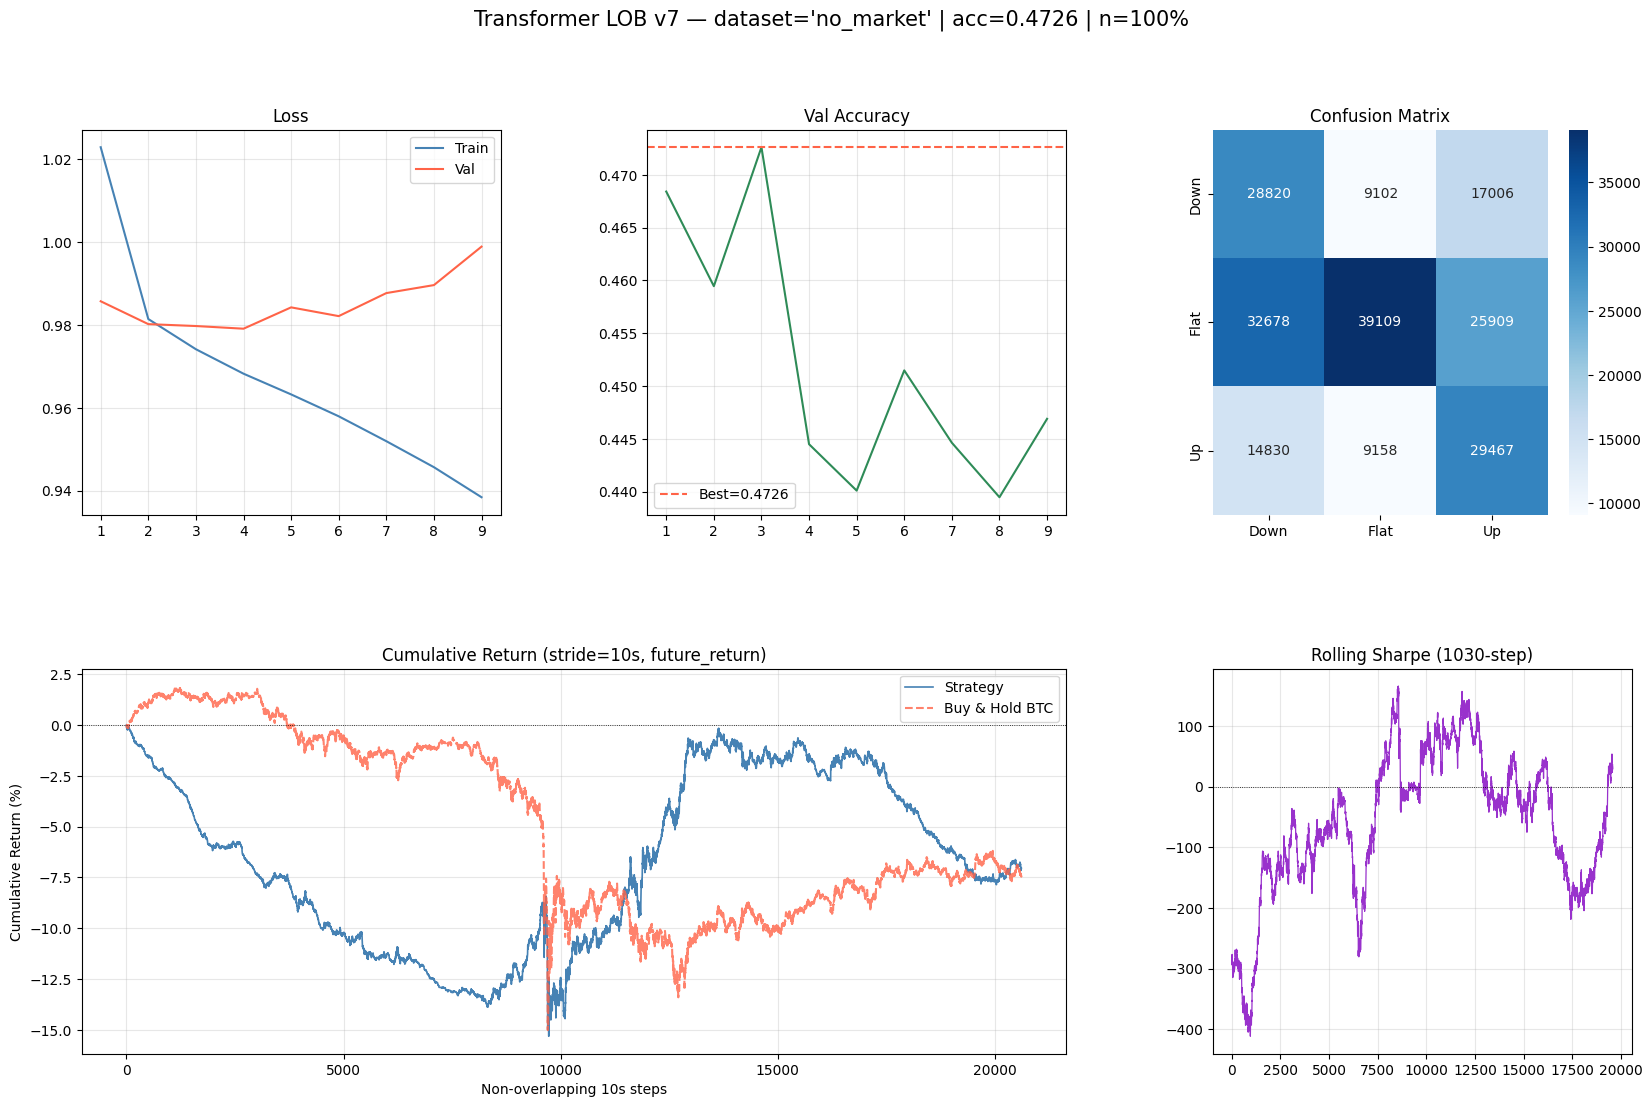

In [3]:
DATASET          = "no_market"
TRANSACTION_COST = 0.00015
model, history, stat_metrics, bt_metrics = run()


1. LOAD DATA
  [RAM] 3.7 / 13.6 GB used
Using Colab cache for faster access to the 'high-frequency-crypto-limit-order-book-data' dataset.
  Loading BTC...
  [RAM] 5.2 / 13.6 GB used
  Loading ETH (selected columns only)...
  [RAM] 5.3 / 13.6 GB used
  Merged df: (1030670, 158)
  [RAM] 4.9 / 13.6 GB used

2. FEATURE ENGINEERING
  Shape after dropna: (1030600, 176)
  [RAM] 5.0 / 13.6 GB used

3. CLASSIC LOB FACTORS
  Shape after factors: (1030540, 189)
  [RAM] 6.2 / 13.6 GB used

  Split index: 824,432 (train) / 206,108 (test)

4. NORMALISATION (split-aware — no leakage)
  Rolling Z-score — LOB features ...
  [RAM] 5.0 / 13.6 GB used
  Rolling Z-score — market features ...
  Rolling Z-score — classic factors ...
  Shape after normalisation: (1030540, 189)
  [RAM] 4.8 / 13.6 GB used

5. INCREMENTAL PCA
  n_components=10, batch_size=50,000
  Cumulative variance explained: 0.573
  [RAM] 4.8 / 13.6 GB used

6. ASSEMBLE DATASETS
  Extracting dataset: 'full_raw'
  X_train: (824432, 88)  X_tes

/tmp/ipykernel_4770/2872524565.py:447: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, N_LAYERS, norm=nn.LayerNorm(D_MODEL))


Ep   1/30 | Train 1.0047 | Val 0.9681 | Acc 0.4513 | LR 2.80e-04
Ep   2/30 | Train 0.9641 | Val 0.9661 | Acc 0.4718 | LR 7.60e-04
Ep   3/30 | Train 0.9553 | Val 0.9671 | Acc 0.4753 | LR 1.00e-03
Ep   4/30 | Train 0.9465 | Val 0.9695 | Acc 0.4741 | LR 9.97e-04
Ep   5/30 | Train 0.9367 | Val 0.9767 | Acc 0.4671 | LR 9.87e-04
Ep   6/30 | Train 0.9252 | Val 0.9849 | Acc 0.4369 | LR 9.70e-04
Ep   7/30 | Train 0.9120 | Val 0.9921 | Acc 0.4331 | LR 9.47e-04
Ep   8/30 | Train 0.8976 | Val 1.0012 | Acc 0.4211 | LR 9.18e-04
Ep   9/30 | Train 0.8830 | Val 1.0222 | Acc 0.4313 | LR 8.83e-04
Early stop. Best acc: 0.4753

--- Prediction ---

  6.1  STATISTICAL PREDICTION METRICS

Overall Accuracy: 0.4753  (47.53%)

              precision    recall  f1-score   support

   Down (-1)     0.3843    0.5362    0.4477     54928
    Flat (0)     0.6976    0.3832    0.4947     97696
     Up (+1)     0.4098    0.5808    0.4805     53455

    accuracy                         0.4753    206079
   macro avg     0

/tmp/ipykernel_4770/2872524565.py:644: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


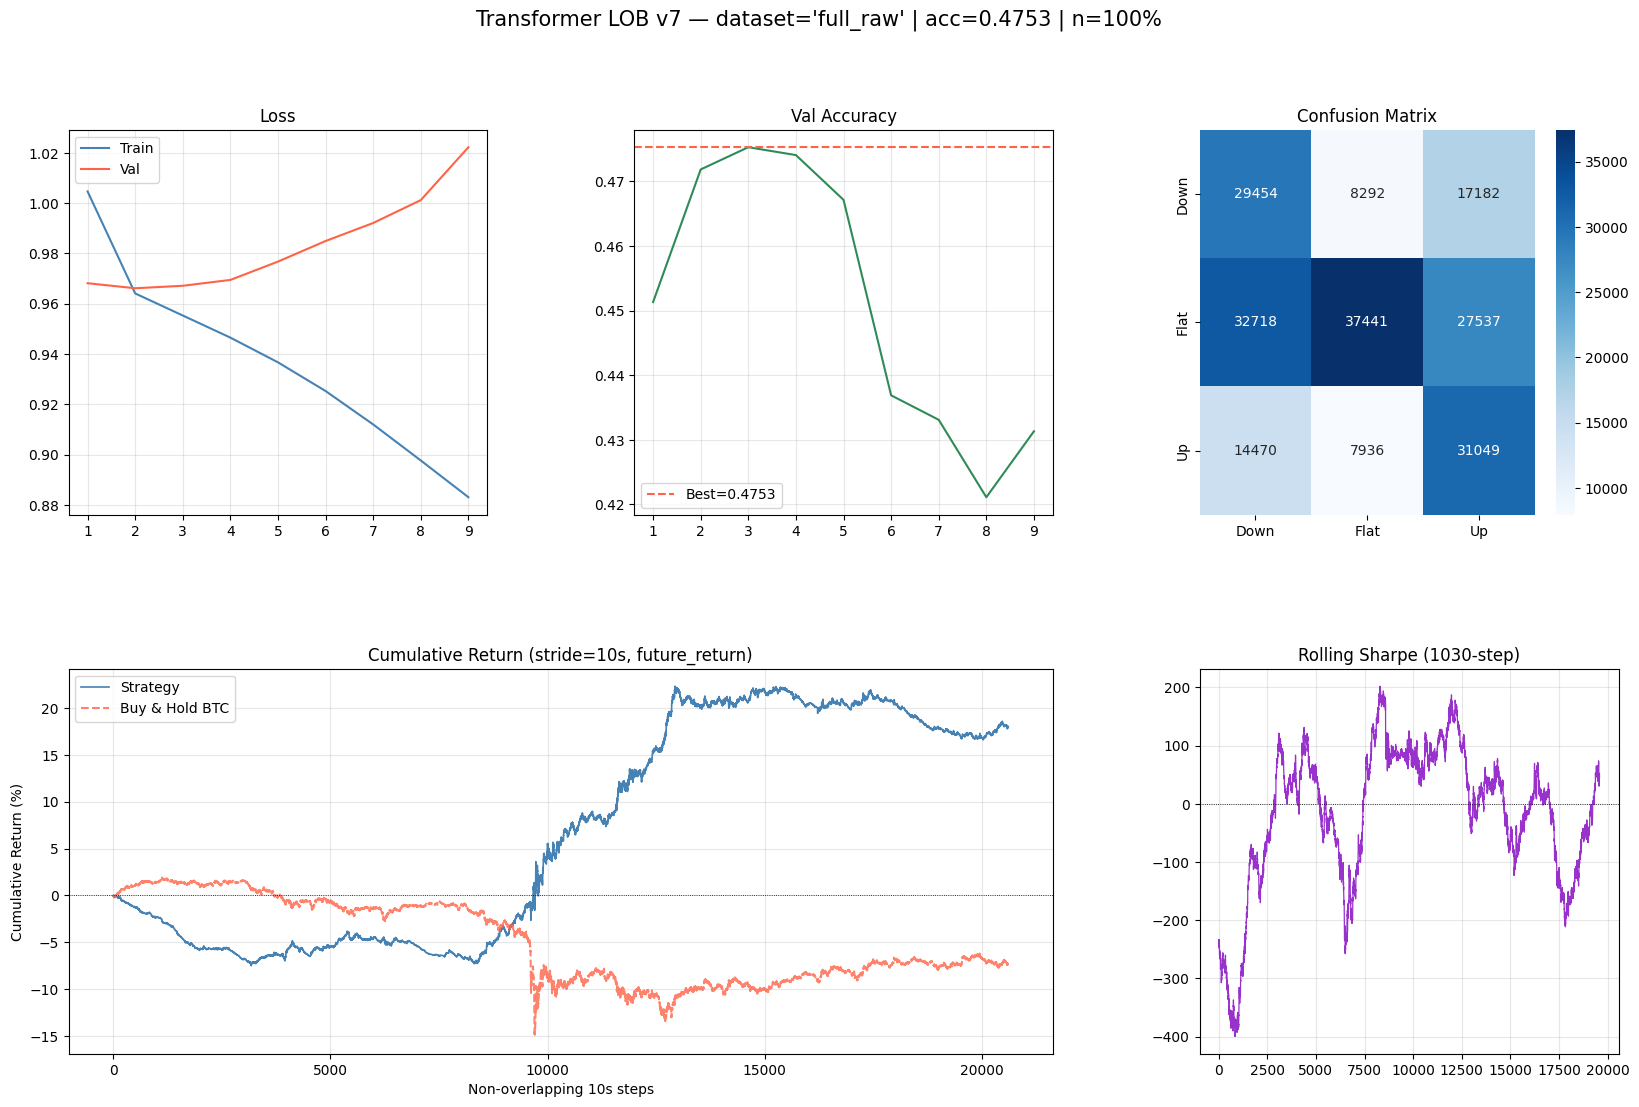

In [8]:
DATASET          = "full_raw"
TRANSACTION_COST = 0.00015
model, history, stat_metrics, bt_metrics = run()